In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from nba_api.stats.endpoints import shotchartdetail

In [99]:
season = "2023-24"
team_id = 1610612738  # Boston Celtics

shots_response = shotchartdetail.ShotChartDetail(
    team_id=team_id,                # id del equipo
    player_id=0,                    # No quiero un jugador concreto quiero el equipo, por eso pongo 0
    season_nullable=season,         # Quiero esta temporada
    season_type_all_star="Regular Season",  # Solo la temporada regular
    context_measure_simple="FGA",   # FGA significa Field Goal Attempts, es decir, intentos de tiro. Queremos todos los tiros intentados, no solo los anotados
    league_id="00",
    timeout=60                      # Le damos más tiempo a la API para responder
)

shots_df = shots_response.shot_chart_detail.get_data_frame()    # Convertimos la respuesta a un DataFrame de pandas

shots_df["SEASON"] = season

shots_df.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,Shot Chart Detail,0022300010,7,201950,Jrue Holiday,1610612738,Boston Celtics,1,11,39,...,Less Than 8 ft.,7,16,71,1,1,20231110,BOS,BKN,2023-24
1,Shot Chart Detail,0022300010,11,1627759,Jaylen Brown,1610612738,Boston Celtics,1,11,13,...,Less Than 8 ft.,3,12,35,1,0,20231110,BOS,BKN,2023-24
2,Shot Chart Detail,0022300010,21,1628369,Jayson Tatum,1610612738,Boston Celtics,1,10,27,...,24+ ft.,28,135,248,1,0,20231110,BOS,BKN,2023-24
3,Shot Chart Detail,0022300010,23,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,22,...,16-24 ft.,18,-134,122,1,1,20231110,BOS,BKN,2023-24
4,Shot Chart Detail,0022300010,30,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,2,...,24+ ft.,27,-147,227,1,1,20231110,BOS,BKN,2023-24


In [100]:
shots_df.shape      # Cuantas filas y columnas tiene el DataFrame

(7396, 25)

In [101]:
shots_df.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'SEASON'],
      dtype='str')

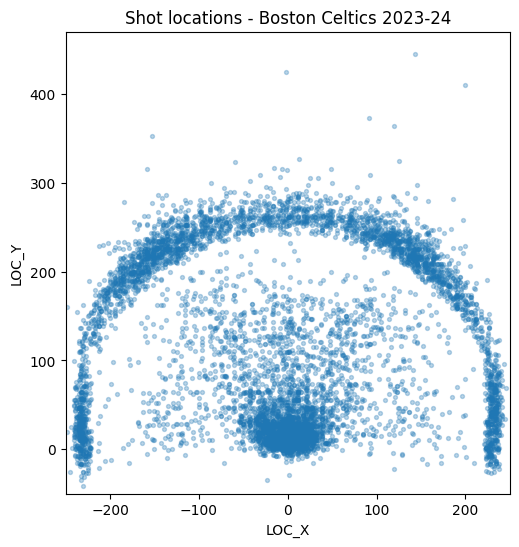

In [102]:
plt.figure(figsize=(6, 6))

plt.scatter(
    shots_df["LOC_X"],
    shots_df["LOC_Y"],
    alpha=0.3,
    s=8
)

plt.title("Shot locations - Boston Celtics 2023-24")
plt.xlabel("LOC_X")
plt.ylabel("LOC_Y")
plt.xlim(-250, 250)
plt.ylim(-50, 470)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [103]:
shots_df.to_csv("../../data/raw/boston_celtics_shots_2023_24.csv", index=False)

In [104]:
shots_df[
    [
        "SEASON",
        "TEAM_NAME",
        "PLAYER_NAME",
        "SHOT_TYPE",
        "SHOT_ZONE_BASIC",
        "SHOT_ZONE_AREA",
        "SHOT_ZONE_RANGE",
        "SHOT_DISTANCE",
        "LOC_X",
        "LOC_Y",
        "SHOT_MADE_FLAG"
    ]
].head(10)

,SEASON,TEAM_NAME,PLAYER_NAME,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_MADE_FLAG
0,2023-24,Boston Celtics,Jrue Holiday,2PT Field Goal,In The Paint (Non-RA),Center(C),Less Than 8 ft.,7,16,71,1
1,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,12,35,0
2,2023-24,Boston Celtics,Jayson Tatum,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,28,135,248,0
3,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Mid-Range,Left Side Center(LC),16-24 ft.,18,-134,122,1
4,2023-24,Boston Celtics,Jaylen Brown,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,27,-147,227,1
5,2023-24,Boston Celtics,Kristaps Porziņģis,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,13,-116,75,1
6,2023-24,Boston Celtics,Jaylen Brown,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,26,-176,197,1
7,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Mid-Range,Right Side Center(RC),16-24 ft.,18,126,135,0
8,2023-24,Boston Celtics,Jrue Holiday,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,26,-178,195,1
9,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,6,36,1


## 2. Clasificación de los tiros por zona

In [105]:
def classify_shot(row):
    if row["SHOT_TYPE"] == "3PT Field Goal":
        return "Three"
    elif row["SHOT_DISTANCE"] <= 8:
        return "Rim"
    else:
        return "Mid-range"


shots_df["SHOT_GROUP"] = shots_df.apply(classify_shot, axis=1)

In [106]:
shots_df[
    [
        "PLAYER_NAME",
        "TEAM_NAME",
        "SHOT_TYPE",
        "SHOT_DISTANCE",
        "SHOT_ZONE_BASIC",
        "SHOT_GROUP",
        "SHOT_MADE_FLAG"
    ]
].head(20)

,PLAYER_NAME,TEAM_NAME,SHOT_TYPE,SHOT_DISTANCE,SHOT_ZONE_BASIC,SHOT_GROUP,SHOT_MADE_FLAG
0,Jrue Holiday,Boston Celtics,2PT Field Goal,7,In The Paint (Non-RA),Rim,1
1,Jaylen Brown,Boston Celtics,2PT Field Goal,3,Restricted Area,Rim,0
2,Jayson Tatum,Boston Celtics,3PT Field Goal,28,Above the Break 3,Three,0
3,Jaylen Brown,Boston Celtics,2PT Field Goal,18,Mid-Range,Mid-range,1
4,Jaylen Brown,Boston Celtics,3PT Field Goal,27,Above the Break 3,Three,1
5,Kristaps Porziņģis,Boston Celtics,2PT Field Goal,13,Mid-Range,Mid-range,1
6,Jaylen Brown,Boston Celtics,3PT Field Goal,26,Above the Break 3,Three,1
7,Jaylen Brown,Boston Celtics,2PT Field Goal,18,Mid-Range,Mid-range,0
8,Jrue Holiday,Boston Celtics,3PT Field Goal,26,Above the Break 3,Three,1
9,Jaylen Brown,Boston Celtics,2PT Field Goal,3,Restricted Area,Rim,1


In [107]:
shots_df["SHOT_GROUP"].value_counts()

SHOT_GROUP
Three        3482
Rim          2785
Mid-range    1129
Name: count, dtype: int64

In [108]:
shots_df["SHOT_GROUP"].value_counts(normalize=True) * 100

SHOT_GROUP
Three        47.079502
Rim          37.655489
Mid-range    15.265008
Name: proportion, dtype: float64

In [109]:
shot_group_summary = (
    shots_df["SHOT_GROUP"]
    .value_counts()
    .reset_index()
)

shot_group_summary.columns = ["SHOT_GROUP", "FGA"]

shot_group_summary["FGA_SHARE"] = (
    shot_group_summary["FGA"] / shot_group_summary["FGA"].sum()
)

shot_group_summary

,SHOT_GROUP,FGA,FGA_SHARE
0,Three,3482,0.470795
1,Rim,2785,0.376555
2,Mid-range,1129,0.152650


In [110]:
shot_group_summary["FGA_SHARE_PCT"] = (
    shot_group_summary["FGA_SHARE"] * 100
).round(2)

shot_group_summary

,SHOT_GROUP,FGA,FGA_SHARE,FGA_SHARE_PCT
0,Three,3482,0.470795,47.08
1,Rim,2785,0.376555,37.66
2,Mid-range,1129,0.152650,15.27


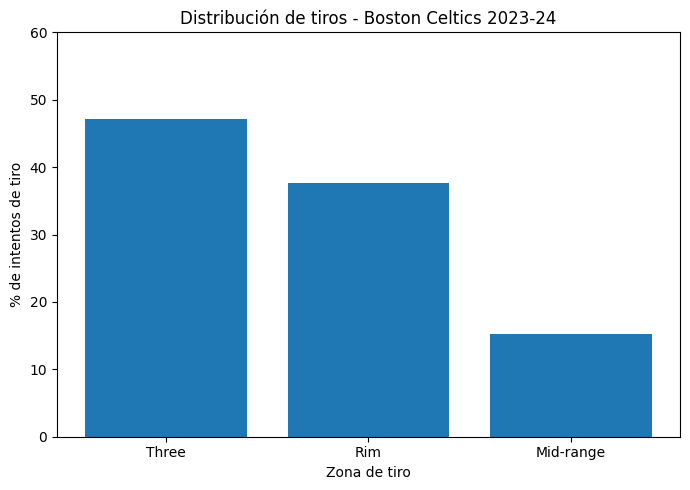

In [111]:
plt.figure(figsize=(7, 5))

plt.bar(
    shot_group_summary["SHOT_GROUP"],
    shot_group_summary["FGA_SHARE_PCT"]
)

plt.title("Distribución de tiros - Boston Celtics 2023-24")
plt.xlabel("Zona de tiro")
plt.ylabel("% de intentos de tiro")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

In [112]:
import os

os.makedirs("../../data/processed/carlos", exist_ok=True)

shots_df.to_csv(
    "../../data/processed/carlos/boston_celtics_shots_2023_24_with_groups.csv",
    index=False
)

shot_group_summary.to_csv(
    "../../data/processed/carlos/boston_celtics_shot_group_summary_2023_24.csv",
    index=False
)

### Primera lectura

En la temporada 2023-24, los Boston Celtics concentraron casi la mitad de sus lanzamientos en el triple y más de un tercio cerca del aro. La media distancia representa una parte mucho menor de su selección de tiro.

Este primer análisis encaja con la idea de la evolución moderna de la NBA: los equipos tienden a priorizar tiros con mayor productividad observada por intento, especialmente triples y lanzamientos cercanos al aro.


## 3. Eficiencia por zona de tiro

In [113]:
# Esto agrupa todos los tiros de Boston 2023-24 por zona.

zone_efficiency = (
    shots_df                                    # DataFrame principal, cada fila representa un tiro
    .groupby("SHOT_GROUP")                      # Agrupa todos los tiros por la columna "SHOT_GROUP", es decir, por zona de tiro (Three, Rim, Mid-range)
    .agg(                                       # Para cada grupo, calculamos dos cosas:
        FGA=("SHOT_ATTEMPTED_FLAG", "sum"),     # Creamos una nueva columna que se llama FGA - Tiros intentados
        FGM=("SHOT_MADE_FLAG", "sum")           # Creamos una nueva columna que se llama FGM - Tiros anotados
    )
    .reset_index()                              # Quiero que SHOT_GROUP vuelva a ser una columna normal.
)

zone_efficiency

,SHOT_GROUP,FGA,FGM
0,Mid-range,1129,502
1,Rim,2785,1748
2,Three,3482,1351


In [114]:
# Calculamos el porcentaje de acierto por zona
# tiros anotados / tiros intentados
# Este dato permite comparar la precisión de cada zona.

zone_efficiency["FG_PCT"] = (
    zone_efficiency["FGM"] / zone_efficiency["FGA"]
)

zone_efficiency


# Pero cuidado: porcentaje de acierto no es lo mismo que valor del tiro.
# Un triple puede tener menos acierto, pero vale más puntos.


,SHOT_GROUP,FGA,FGM,FG_PCT
0,Mid-range,1129,502,0.444641
1,Rim,2785,1748,0.627648
2,Three,3482,1351,0.387995


In [115]:
# Puntos por intento según zona

# De media, ¿cuántos puntos produjo cada lanzamiento desde esta zona?
# puntos por intento = porcentaje de acierto observado × valor del tiro

# Un tiro de dos vale 2 puntos.
# Un triple vale 3 puntos.

# Por eso, aunque el triple tenga menor porcentaje de acierto, puede ser más rentable.

def calculate_points_per_attempt(row):
    if row["SHOT_GROUP"] == "Three":
        return row["FG_PCT"] * 3
    else:
        return row["FG_PCT"] * 2


zone_efficiency["POINTS_PER_ATTEMPT"] = zone_efficiency.apply(
    calculate_points_per_attempt,
    axis=1                              # Aplicamos la función fila por fila
)

zone_efficiency


,SHOT_GROUP,FGA,FGM,FG_PCT,POINTS_PER_ATTEMPT
0,Mid-range,1129,502,0.444641,0.889283
1,Rim,2785,1748,0.627648,1.255296
2,Three,3482,1351,0.387995,1.163986


##### Aunque el triple tiene un porcentaje de acierto menor, puede ser más productivo en puntos por intento porque vale tres puntos.


In [116]:
zone_efficiency["FG_PCT"] = zone_efficiency["FG_PCT"].round(3)
zone_efficiency["POINTS_PER_ATTEMPT"] = zone_efficiency["POINTS_PER_ATTEMPT"].round(3)

zone_efficiency


,SHOT_GROUP,FGA,FGM,FG_PCT,POINTS_PER_ATTEMPT
0,Mid-range,1129,502,0.445,0.889
1,Rim,2785,1748,0.628,1.255
2,Three,3482,1351,0.388,1.164


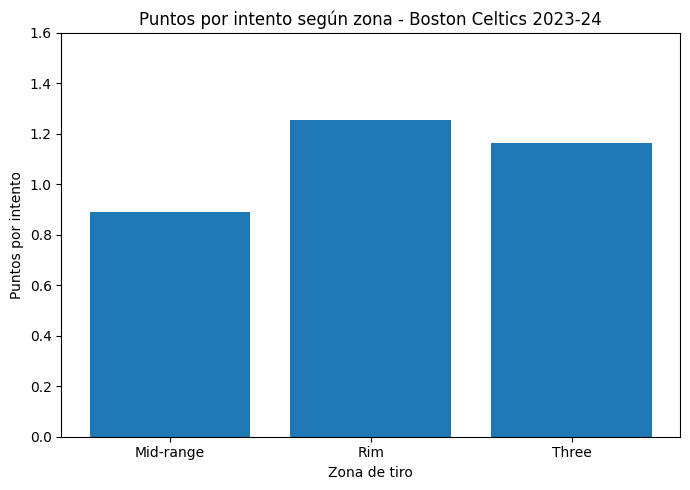

In [117]:
# GRÁFICA DE PUNTOS POR INTENTO SEGÚN ZONA
# ¿Qué tipo de tiro produjo más puntos por intento? ¿Desde qué zona se generaron más puntos por lanzamiento?

plt.figure(figsize=(7, 5))

plt.bar(
    zone_efficiency["SHOT_GROUP"],
    zone_efficiency["POINTS_PER_ATTEMPT"]
)

plt.title("Puntos por intento según zona - Boston Celtics 2023-24")
plt.xlabel("Zona de tiro")
plt.ylabel("Puntos por intento")
plt.ylim(0, 1.6)
plt.tight_layout()
plt.show()


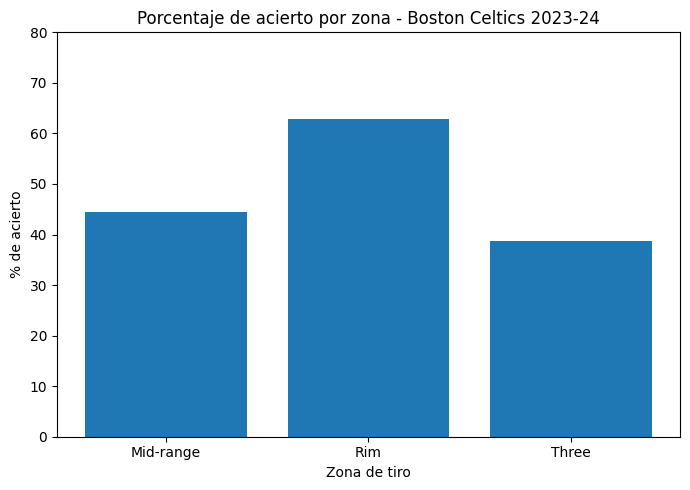

In [118]:
# ¿Desde qué zona se mete más porcentaje de tiros?

plt.figure(figsize=(7, 5))

plt.bar(
    zone_efficiency["SHOT_GROUP"],
    zone_efficiency["FG_PCT"] * 100
)

plt.title("Porcentaje de acierto por zona - Boston Celtics 2023-24")
plt.xlabel("Zona de tiro")
plt.ylabel("% de acierto")
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

In [119]:
zone_efficiency.to_csv(
    "../../data/processed/carlos/boston_celtics_zone_efficiency_2023_24.csv",
    index=False
)

### Lectura de eficiencia

En los Boston Celtics 2023-24, los tiros de media distancia tuvieron un acierto del 44.5%, pero generaron únicamente 0.889 puntos por intento.

En comparación, los triples, pese a tener un menor porcentaje de acierto, generaron 1.164 puntos por intento gracias a su valor de tres puntos. Los tiros cerca del aro fueron los más productivos, con 1.255 puntos por intento.

Esto ayuda a explicar por qué el equipo concentra la mayoría de sus lanzamientos en triples y tiros cerca del aro, reduciendo el peso de la media distancia. No se trata solo de una cuestión de volumen, sino de productividad real observada por lanzamiento.


## Vamos a dibujar la cancha

In [120]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc

In [121]:
def draw_court(ax=None, color="black", lw=2, outer_lines=False):
    """
    Dibuja una media cancha NBA usando matplotlib.
    """
    if ax is None:
        ax = plt.gca()

    # Aro
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)

    # Tablero
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)

    # Zona exterior
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)

    # Zona interior
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)

    # Semicírculo superior de tiro libre
    top_free_throw = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color, fill=False)

    # Semicírculo inferior de tiro libre
    bottom_free_throw = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle="dashed")

    # Zona restringida
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)

    # Línea de triple frontal
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)

    # Arco de triple
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)

    # Arco central
    center_outer_arc = Arc((0, 422.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color)
    center_inner_arc = Arc((0, 422.5), 40, 40, theta1=180, theta2=0, linewidth=lw, color=color)

    court_elements = [
        hoop,
        backboard,
        outer_box,
        inner_box,
        top_free_throw,
        bottom_free_throw,
        restricted,
        corner_three_a,
        corner_three_b,
        three_arc,
        center_outer_arc,
        center_inner_arc
    ]

    if outer_lines:
        outer = Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        court_elements.append(outer)

    for element in court_elements:
        ax.add_patch(element)

    return ax

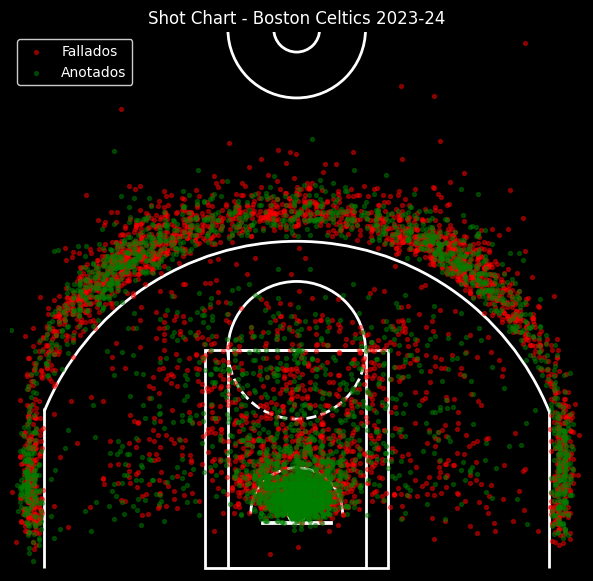

In [122]:
import os
# Ahora creamos la gráfica de los tiros con la cancha dibujada debajo

# Separamos los tiros anotados de los fallados para pintarlos de colores diferentes
made_shots = shots_df[shots_df["SHOT_MADE_FLAG"] == 1]          # Obtenemos un DataFrame con solo los tiros anotados
missed_shots = shots_df[shots_df["SHOT_MADE_FLAG"] == 0]        # Obtenemos un DataFrame con solo los tiros fallados

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("black")                                # Cambiamos el color del fondo de la pista
ax.set_facecolor("black")

# Usamos una función auxiliar que dibuja una media cancha NBA con matplotlib y luego representamos los tiros encima.
draw_court(ax, color="white", lw=2, outer_lines=False)          # Dibujamos la cancha con líneas blancas

# Creamos el gráfico de dispersión de los tiros, usando un color para los anotados y otro para los fallados.
ax.scatter(
    missed_shots["LOC_X"],
    missed_shots["LOC_Y"],
    c="red",
    s=8,
    alpha=0.45,
    label="Fallados"
)

ax.scatter(
    made_shots["LOC_X"],
    made_shots["LOC_Y"],
    c="green",
    s=8,
    alpha=0.45,
    label="Anotados"
)

ax.set_title("Shot Chart - Boston Celtics 2023-24", color="white")
ax.set_xlim(-250, 250)
ax.set_ylim(-50, 420)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(facecolor="black", edgecolor="white", labelcolor="white")


# Guardamos la visualización antes de mostrarla para conservar la figura correctamente
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/shot_chart_boston_celtics_2023_24.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


## 5. Comparativa histórica por equipos


In [123]:
teams_to_analyze = [
    {
        "TEAM_NAME": "Chicago Bulls",               # Representan el estilo clásico de los 90: mucho peso de la media distancia, aclarados, poste bajo y menor volumen de triple.
        "TEAM_ID": 1610612741,
        "SEASON": "1997-98",
        "LABEL": "Bulls 1997-98"
    },
    {
        "TEAM_NAME": "Los Angeles Lakers",          # Otro estilo premoderno: dominio interior con Shaq cerca del aro y Kobe como tirador de media distancia. Mucho menos triple que un equipo actual, pero con dos superestrellas dominantes.
        "TEAM_ID": 1610612747,
        "SEASON": "2000-01",
        "LABEL": "Lakers 2000-01"
    },
    {
        "TEAM_NAME": "Golden State Warriors",       # Imprescindibles. Representan el gran punto de ruptura: Curry, Klay, Draymond, Iguodala... el equipo que cambió la forma de jugar al baloncesto.
        "TEAM_ID": 1610612744,
        "SEASON": "2015-16",
        "LABEL": "Warriors 2015-16"
    },
    {
        "TEAM_NAME": "Boston Celtics",              # El ejemplo moderno: muchos triples, cinco jugadores abiertos, equipo ganador reciente
        "TEAM_ID": 1610612738,
        "SEASON": "2023-24",
        "LABEL": "Celtics 2023-24"
    }
]

teams_to_analyze


[{'TEAM_NAME': 'Chicago Bulls',
  'TEAM_ID': 1610612741,
  'SEASON': '1997-98',
  'LABEL': 'Bulls 1997-98'},
 {'TEAM_NAME': 'Los Angeles Lakers',
  'TEAM_ID': 1610612747,
  'SEASON': '2000-01',
  'LABEL': 'Lakers 2000-01'},
 {'TEAM_NAME': 'Golden State Warriors',
  'TEAM_ID': 1610612744,
  'SEASON': '2015-16',
  'LABEL': 'Warriors 2015-16'},
 {'TEAM_NAME': 'Boston Celtics',
  'TEAM_ID': 1610612738,
  'SEASON': '2023-24',
  'LABEL': 'Celtics 2023-24'}]

In [124]:
# Función para descargar tiros

import time
from nba_api.stats.endpoints import shotchartdetail

def get_team_shots(team_id, season, team_label=None, sleep_time=1):
    """
    Descarga los tiros de un equipo en una temporada usando nba_api.

    Parámetros:
    - team_id: identificador del equipo NBA.
    - season: temporada en formato 'YYYY-YY', por ejemplo '2023-24'.
    - team_label: nombre descriptivo para identificar el caso.
    - sleep_time: pausa para no saturar la API.

    Devuelve:
    - DataFrame con los tiros del equipo en esa temporada.
    """

    print(f"Descargando tiros de {team_label}...")

    response = shotchartdetail.ShotChartDetail(
        team_id=team_id,
        player_id=0,
        season_nullable=season,
        season_type_all_star="Regular Season",
        context_measure_simple="FGA",
        league_id="00",
        timeout=60
    )

    df = response.shot_chart_detail.get_data_frame()

    df["SEASON"] = season
    df["TEAM_LABEL"] = team_label

    time.sleep(sleep_time)

    return df

In [125]:
# Descargamos los tiros de todos los equipos que queremos analizar y los guardamos en una lista de DataFrames

all_team_shots = []

for team in teams_to_analyze:
    df_team = get_team_shots(
        team_id=team["TEAM_ID"],
        season=team["SEASON"],
        team_label=team["LABEL"],
        sleep_time=1
    )

    all_team_shots.append(df_team)

Descargando tiros de Bulls 1997-98...
Descargando tiros de Lakers 2000-01...
Descargando tiros de Warriors 2015-16...
Descargando tiros de Celtics 2023-24...


In [126]:
historical_shots = pd.concat(all_team_shots, ignore_index=True)

historical_shots.shape

(28041, 26)

In [127]:
historical_shots[["TEAM_LABEL", "TEAM_NAME", "SEASON", "PLAYER_NAME", "SHOT_TYPE", "SHOT_DISTANCE", "LOC_X", "LOC_Y"]].head()

,TEAM_LABEL,TEAM_NAME,SEASON,PLAYER_NAME,SHOT_TYPE,SHOT_DISTANCE,LOC_X,LOC_Y
0,Bulls 1997-98,Chicago Bulls,1997-98,Jason Caffey,2PT Field Goal,12.0,119.0,16.0
1,Bulls 1997-98,Chicago Bulls,1997-98,Jason Caffey,2PT Field Goal,1.0,10.0,10.0
2,Bulls 1997-98,Chicago Bulls,1997-98,Jason Caffey,2PT Field Goal,1.0,10.0,-3.0
3,Bulls 1997-98,Chicago Bulls,1997-98,Jason Caffey,2PT Field Goal,0.0,-3.0,0.0
4,Bulls 1997-98,Chicago Bulls,1997-98,Toni Kukoc,2PT Field Goal,16.0,-164.0,29.0


In [128]:
# Cuantos tiros tenemos de cada equipo?
historical_shots["TEAM_LABEL"].value_counts()

TEAM_LABEL
Celtics 2023-24     7396
Warriors 2015-16    7159
Bulls 1997-98       6801
Lakers 2000-01      6685
Name: count, dtype: int64

In [129]:
# Clasificamos de nuevo los tiros como hemos hecho con los Celtics, pero ahora para todos los equipos.

def classify_shot(row):
    if row["SHOT_TYPE"] == "3PT Field Goal":
        return "Three"
    elif row["SHOT_DISTANCE"] <= 8:
        return "Rim"
    else:
        return "Mid-range"
    
historical_shots["SHOT_GROUP"] = historical_shots.apply(classify_shot, axis=1)
historical_shots["SHOT_GROUP"].value_counts()

SHOT_GROUP
Rim          11396
Mid-range     8334
Three         8311
Name: count, dtype: int64

In [130]:
# Creamos resumen por equipo y zona de tiro

historical_profile = (
    historical_shots
    .groupby(["TEAM_LABEL", "SEASON", "TEAM_NAME", "SHOT_GROUP"])
    .agg(
        FGA=("SHOT_ATTEMPTED_FLAG", "sum"),         # Creamos una nueva columna que se llama FGA - Tiros intentados
        FGM=("SHOT_MADE_FLAG", "sum")               # Creamos una nueva columna que se llama FGM - Tiros anotados
    )
    .reset_index()
)

historical_profile["FG_PCT"] = (
    historical_profile["FGM"] / historical_profile["FGA"]           # Porcentaje de acierto por zona
)

historical_profile["POINTS_PER_ATTEMPT"] = historical_profile.apply(
    calculate_points_per_attempt,
    axis=1
)

historical_profile


,TEAM_LABEL,SEASON,TEAM_NAME,SHOT_GROUP,FGA,FGM,FG_PCT,POINTS_PER_ATTEMPT
0,Bulls 1997-98,1997-98,Chicago Bulls,Mid-range,3128,1240,0.396419,0.792839
1,Bulls 1997-98,1997-98,Chicago Bulls,Rim,2711,1513,0.558097,1.116193
2,Bulls 1997-98,1997-98,Chicago Bulls,Three,962,311,0.323285,0.969854
3,Celtics 2023-24,2023-24,Boston Celtics,Mid-range,1129,502,0.444641,0.889283
4,Celtics 2023-24,2023-24,Boston Celtics,Rim,2785,1748,0.627648,1.255296
5,Celtics 2023-24,2023-24,Boston Celtics,Three,3482,1351,0.387995,1.163986
6,Lakers 2000-01,2000-01,Los Angeles Lakers,Mid-range,2444,977,0.399755,0.799509
7,Lakers 2000-01,2000-01,Los Angeles Lakers,Rim,2966,1693,0.570802,1.141605
8,Lakers 2000-01,2000-01,Los Angeles Lakers,Three,1275,439,0.344314,1.032941
9,Warriors 2015-16,2015-16,Golden State Warriors,Mid-range,1633,710,0.434783,0.869565


In [131]:
# Calculamos el porcentaje de tiros por zona para cada equipo

historical_profile["TOTAL_FGA_TEAM"] = (                        # Total de tiros intentados por cada equipo, sin importar la zona. Esto lo hacemos para poder calcular el porcentaje de tiros por zona.
    historical_profile
    .groupby("TEAM_LABEL")["FGA"]
    .transform("sum")
)

historical_profile["FGA_SHARE"] = (                             # Proporción de tiros por zona, es decir, qué parte de los tiros de cada equipo se hacen desde cada zona.
    historical_profile["FGA"] / historical_profile["TOTAL_FGA_TEAM"]
)

historical_profile["FGA_SHARE_PCT"] = (                         # Lo mismo pero en porcentaje, para que sea más fácil de interpretar.
    historical_profile["FGA_SHARE"] * 100
).round(2)

historical_profile["FG_PCT"] = historical_profile["FG_PCT"].round(3)
historical_profile["POINTS_PER_ATTEMPT"] = historical_profile["POINTS_PER_ATTEMPT"].round(3)

historical_profile


,TEAM_LABEL,SEASON,TEAM_NAME,SHOT_GROUP,FGA,FGM,FG_PCT,POINTS_PER_ATTEMPT,TOTAL_FGA_TEAM,FGA_SHARE,FGA_SHARE_PCT
0,Bulls 1997-98,1997-98,Chicago Bulls,Mid-range,3128,1240,0.396,0.793,6801,0.459932,45.99
1,Bulls 1997-98,1997-98,Chicago Bulls,Rim,2711,1513,0.558,1.116,6801,0.398618,39.86
2,Bulls 1997-98,1997-98,Chicago Bulls,Three,962,311,0.323,0.970,6801,0.141450,14.14
3,Celtics 2023-24,2023-24,Boston Celtics,Mid-range,1129,502,0.445,0.889,7396,0.152650,15.27
4,Celtics 2023-24,2023-24,Boston Celtics,Rim,2785,1748,0.628,1.255,7396,0.376555,37.66
5,Celtics 2023-24,2023-24,Boston Celtics,Three,3482,1351,0.388,1.164,7396,0.470795,47.08
6,Lakers 2000-01,2000-01,Los Angeles Lakers,Mid-range,2444,977,0.400,0.800,6685,0.365595,36.56
7,Lakers 2000-01,2000-01,Los Angeles Lakers,Rim,2966,1693,0.571,1.142,6685,0.443680,44.37
8,Lakers 2000-01,2000-01,Los Angeles Lakers,Three,1275,439,0.344,1.033,6685,0.190726,19.07
9,Warriors 2015-16,2015-16,Golden State Warriors,Mid-range,1633,710,0.435,0.870,7159,0.228104,22.81


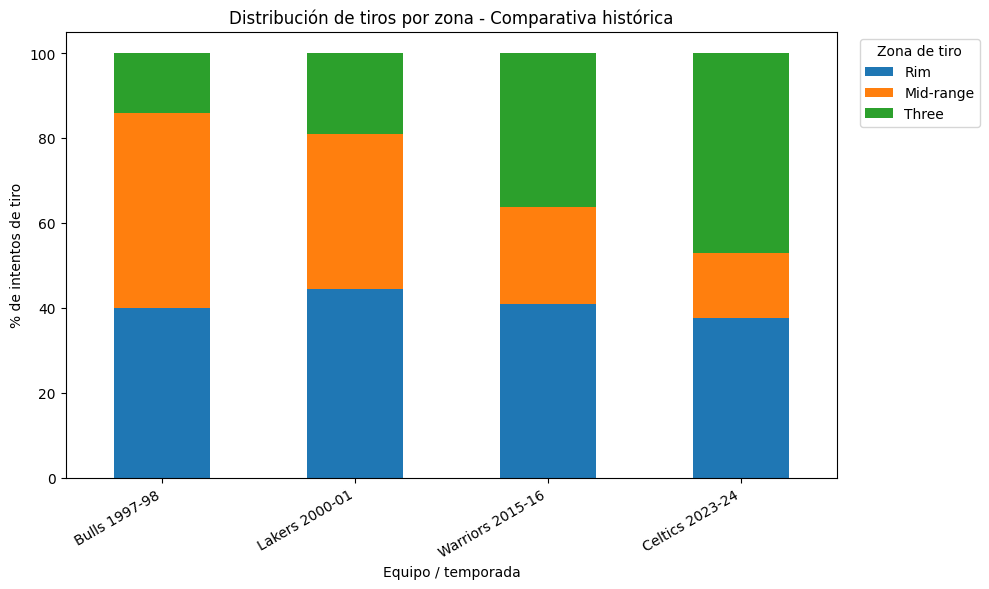

In [132]:
import os
# Gráfico comparativo de distribución de tiros por zona para cada equipo
team_order = [
    "Bulls 1997-98",
    "Lakers 2000-01",
    "Warriors 2015-16",
    "Celtics 2023-24"
]

shot_order = ["Rim", "Mid-range", "Three"]

profile_pivot = historical_profile.pivot_table(
    index="TEAM_LABEL",
    columns="SHOT_GROUP",
    values="FGA_SHARE_PCT",
    fill_value=0
)

profile_pivot = profile_pivot.reindex(team_order)
profile_pivot = profile_pivot[shot_order]

ax = profile_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de tiros por zona - Comparativa histórica")
plt.xlabel("Equipo / temporada")
plt.ylabel("% de intentos de tiro")
plt.xticks(rotation=30, ha="right")

plt.legend(
    title="Zona de tiro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/historical_shot_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


La comparativa histórica muestra un cambio claro en la selección de tiro. Los Bulls 1997-98 y los Lakers 2000-01 concentran una parte muy importante de sus lanzamientos en la media distancia y cerca del aro, mientras que el volumen de triple es mucho menor.

A partir de los Warriors 2015-16 se observa un aumento claro del peso del triple. Esta tendencia se acentúa todavía más en los Celtics 2023-24, donde el triple representa casi la mitad de los intentos de tiro.

Esto refleja la evolución de la NBA hacia modelos ofensivos basados en spacing, tiro exterior y reducción progresiva del mid-range.

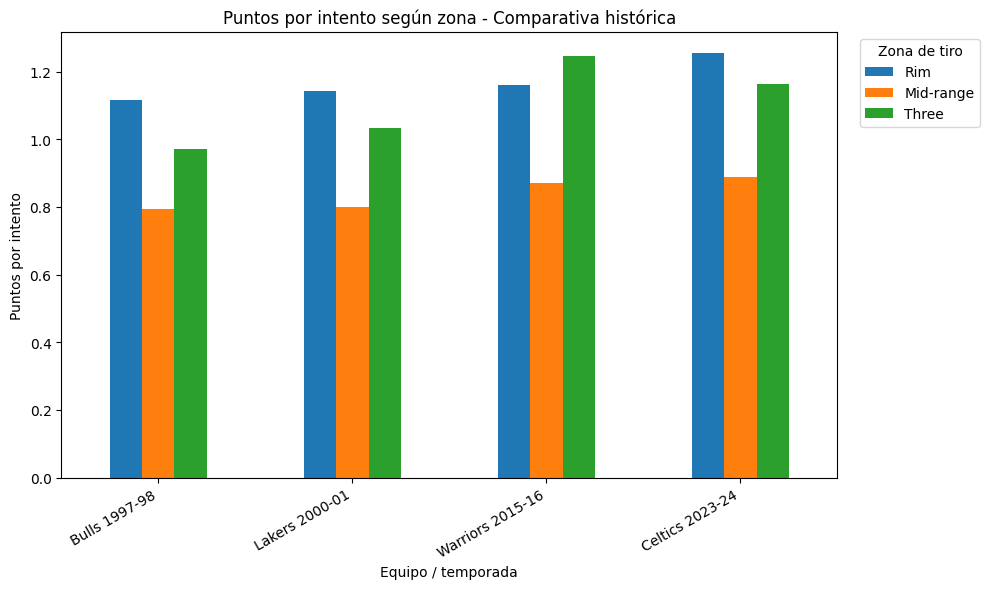

In [133]:
import os
# Gráfico para comparar la productividad por zona de cada equipo

efficiency_pivot = historical_profile.pivot_table(
    index="TEAM_LABEL",
    columns="SHOT_GROUP",
    values="POINTS_PER_ATTEMPT",
    fill_value=0
)

efficiency_pivot = efficiency_pivot.reindex(team_order)
efficiency_pivot = efficiency_pivot[shot_order]

ax = efficiency_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Puntos por intento según zona - Comparativa histórica")
plt.xlabel("Equipo / temporada")
plt.ylabel("Puntos por intento")
plt.xticks(rotation=30, ha="right")

plt.legend(
    title="Zona de tiro",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/historical_points_per_attempt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


La comparación de puntos por intento refuerza la explicación del cambio en la selección de tiro. En los cuatro casos analizados, la media distancia genera menos puntos por intento que los tiros cerca del aro y que el triple.

Esto ayuda a entender por qué los equipos modernos reducen el volumen de lanzamientos de media distancia: no se trata únicamente de una moda táctica, sino de una decisión respaldada por la productividad real observada de cada zona.


In [134]:
import os

os.makedirs("../../data/processed/carlos", exist_ok=True)

historical_shots.to_csv(
    "../../data/processed/carlos/historical_team_shots.csv",
    index=False
)

historical_profile.to_csv(
    "../../data/processed/carlos/historical_team_shot_profile.csv",
    index=False
)

## Comparativa generacional del tiro

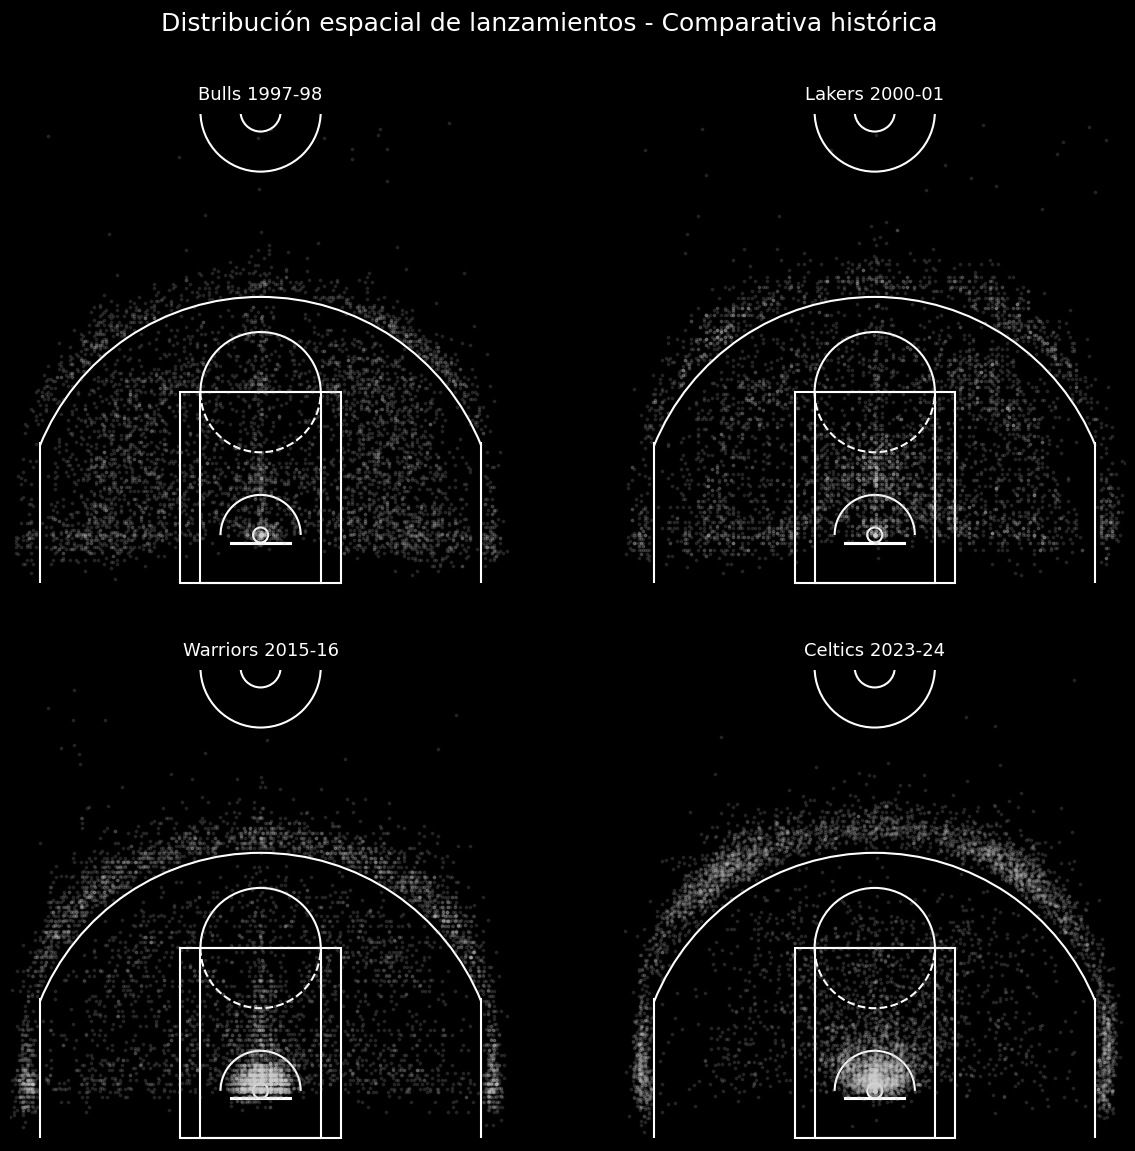

In [135]:
import os
team_order = [
    "Bulls 1997-98",
    "Lakers 2000-01",
    "Warriors 2015-16",
    "Celtics 2023-24"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.patch.set_facecolor("black")
fig.subplots_adjust(wspace=0.12, hspace=0.18, top=0.90)

axes = axes.flatten()

for ax, team_label in zip(axes, team_order):
    team_data = historical_shots[historical_shots["TEAM_LABEL"] == team_label]

    ax.set_facecolor("black")
    draw_court(ax, color="white", lw=1.5, outer_lines=False)

    ax.scatter(
        team_data["LOC_X"],
        team_data["LOC_Y"],
        c="lightgray",
        s=3,
        alpha=0.12
    )

    ax.set_title(team_label, color="white", fontsize=13, pad=10)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(
    "Distribución espacial de lanzamientos - Comparativa histórica",
    color="white",
    fontsize=18
)


# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/shot_chart_matrix_spatial_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


Aquí vemos visualmente cómo evoluciona la distribución espacial del tiro. Los Bulls de 1997-98 y los Lakers de 2000-01 presentan mucha más presencia en media distancia, mientras que los Warriors de 2015-16 y, sobre todo, los Celtics de 2023-24, concentran mucho más volumen en la línea de triple y cerca del aro.

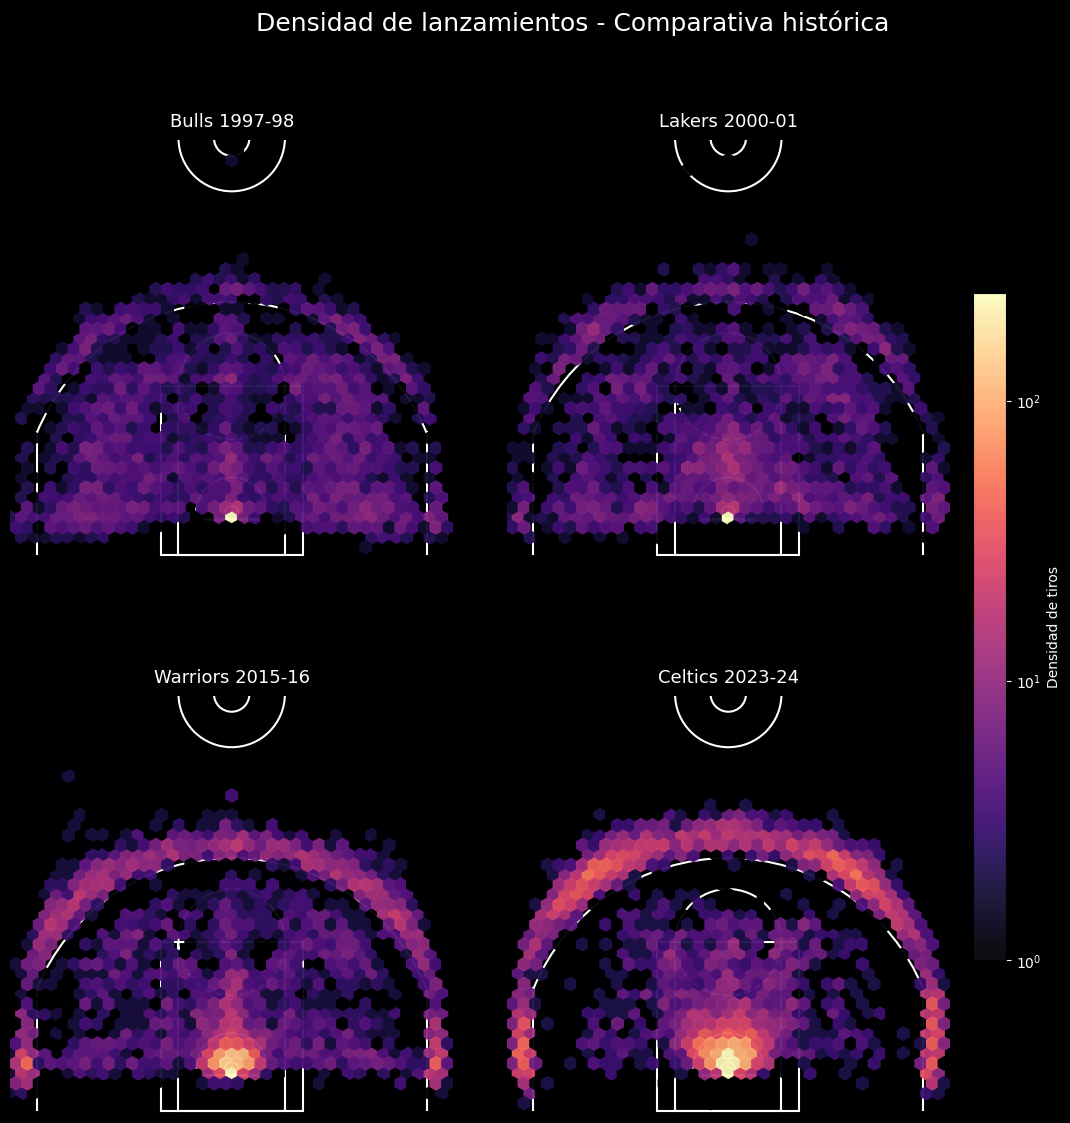

In [136]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Para la visualización de densidad usamos una escala logarítmica. Esto permite reducir el efecto dominante de las zonas con muchísimos lanzamientos, como el aro, y hacer más visibles otras áreas de la pista. 
# Así se aprecia mejor la evolución del patrón de tiro entre equipos y épocas.


team_order = [
    "Bulls 1997-98",
    "Lakers 2000-01",
    "Warriors 2015-16",
    "Celtics 2023-24"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.patch.set_facecolor("black")
fig.subplots_adjust(wspace=0.12, hspace=0.18, top=0.90, right=0.88)

axes = axes.flatten()
hb = None

for ax, team_label in zip(axes, team_order):
    team_data = historical_shots[historical_shots["TEAM_LABEL"] == team_label]

    ax.set_facecolor("black")
    draw_court(ax, color="white", lw=1.5, outer_lines=False)

    hb = ax.hexbin(
        team_data["LOC_X"],
        team_data["LOC_Y"],
        gridsize=38,
        extent=(-250, 250, -50, 420),
        mincnt=1,
        cmap="magma",
        norm=LogNorm(),
        alpha=0.95
    )

    ax.set_title(team_label, color="white", fontsize=13, pad=10)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(
    "Densidad de lanzamientos - Comparativa histórica",
    color="white",
    fontsize=18
)

cbar = fig.colorbar(hb, ax=axes, shrink=0.65, pad=0.02)
cbar.set_label("Densidad de tiros", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")


# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/shot_chart_matrix_density_log.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


Si en lugar de ver puntos individuales miramos densidad de tiro, la tendencia se ve todavía más clara: el volumen de lanzamientos se desplaza progresivamente hacia el triple y la pintura

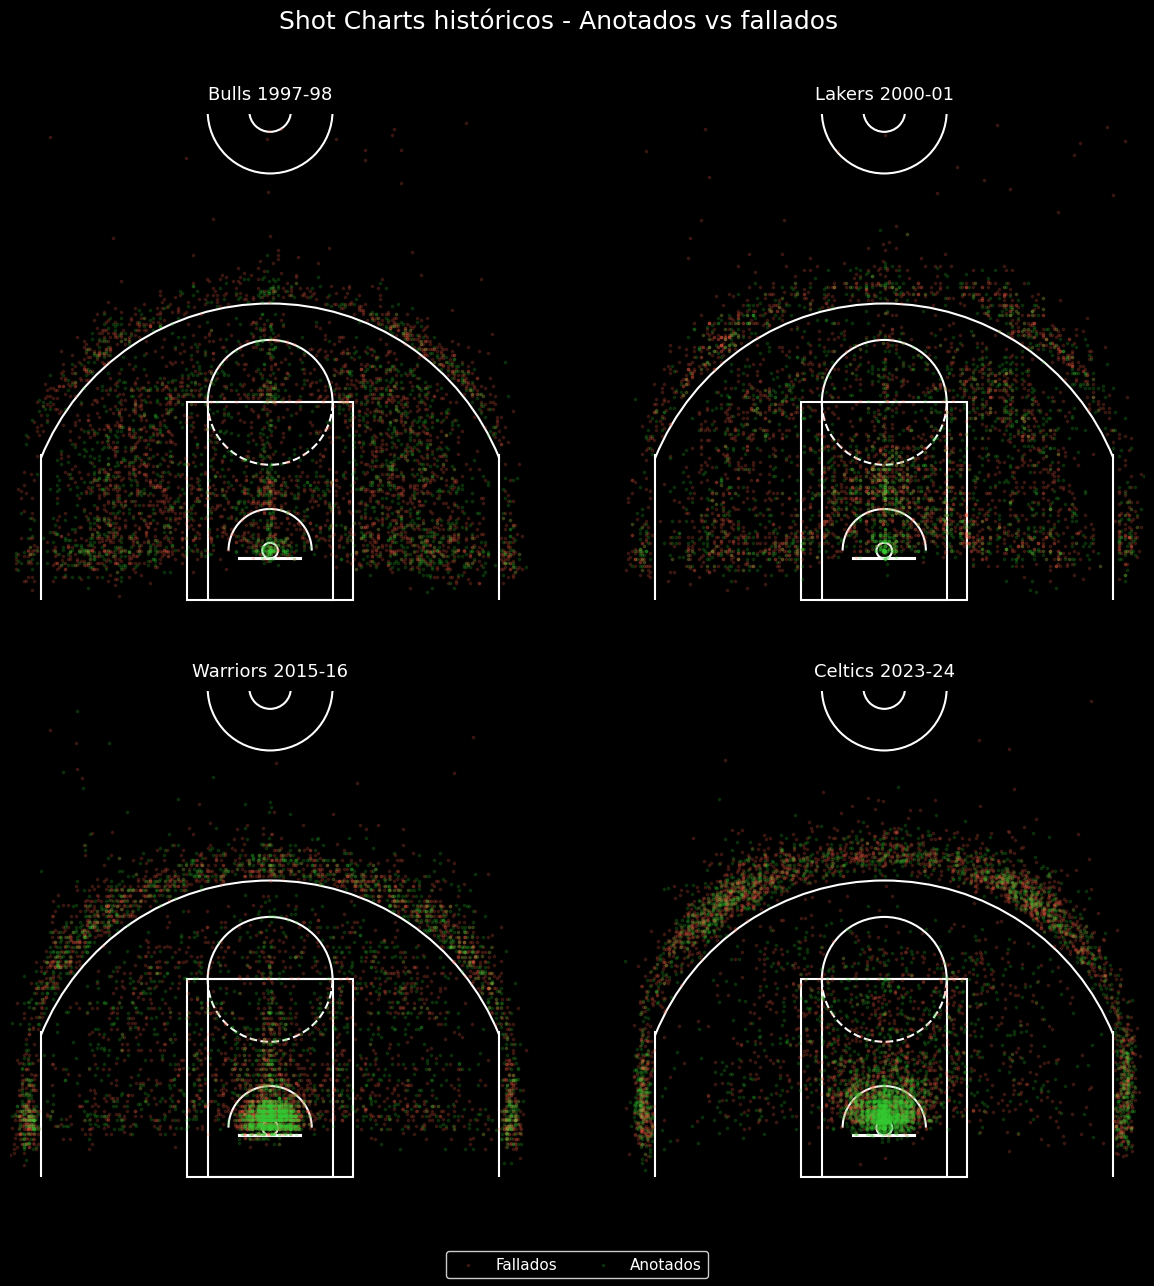

In [137]:
import os
import matplotlib.pyplot as plt

team_order = [
    "Bulls 1997-98",
    "Lakers 2000-01",
    "Warriors 2015-16",
    "Celtics 2023-24"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
fig.patch.set_facecolor("black")
fig.subplots_adjust(wspace=0.12, hspace=0.18, top=0.90, bottom=0.08)

axes = axes.flatten()

for ax, team_label in zip(axes, team_order):
    team_data = historical_shots[historical_shots["TEAM_LABEL"] == team_label]

    made_shots = team_data[team_data["SHOT_MADE_FLAG"] == 1]
    missed_shots = team_data[team_data["SHOT_MADE_FLAG"] == 0]

    ax.set_facecolor("black")
    draw_court(ax, color="white", lw=1.5, outer_lines=False)

    ax.scatter(
        missed_shots["LOC_X"],
        missed_shots["LOC_Y"],
        c="tomato",
        s=3,
        alpha=0.16,
        label="Fallados"
    )

    ax.scatter(
        made_shots["LOC_X"],
        made_shots["LOC_Y"],
        c="limegreen",
        s=3,
        alpha=0.16,
        label="Anotados"
    )

    ax.set_title(team_label, color="white", fontsize=13, pad=10)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.set_aspect("equal")
    ax.axis("off")

fig.suptitle(
    "Shot Charts históricos - Anotados vs fallados",
    color="white",
    fontsize=18
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    fontsize=11
)


# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/shot_chart_matrix_made_vs_missed.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


Por último, diferenciamos los tiros anotados y fallados. 

## Tabla resumen final por equipo

In [138]:

# FGA_SHARE_PCT -> Proporción de tiros por zona, es decir, qué parte de los tiros de cada equipo se hacen desde cada zona. En tanto por ciento

summary_table = historical_profile.pivot_table(
    index="TEAM_LABEL",
    columns="SHOT_GROUP",
    values=["FGA_SHARE_PCT", "POINTS_PER_ATTEMPT"],
    fill_value=0
)

summary_table = summary_table.reindex(team_order)
summary_table

FGA_SHARE_PCT               POINTS_PER_ATTEMPT              
SHOT_GROUP           Mid-range    Rim  Three          Mid-range    Rim  Three
TEAM_LABEL                                                                   
Bulls 1997-98            45.99  39.86  14.14              0.793  1.116  0.970
Lakers 2000-01           36.56  44.37  19.07              0.800  1.142  1.033
Warriors 2015-16         22.81  40.98  36.21              0.870  1.160  1.247
Celtics 2023-24          15.27  37.66  47.08              0.889  1.255  1.164

## Evolución del porcentaje por zona

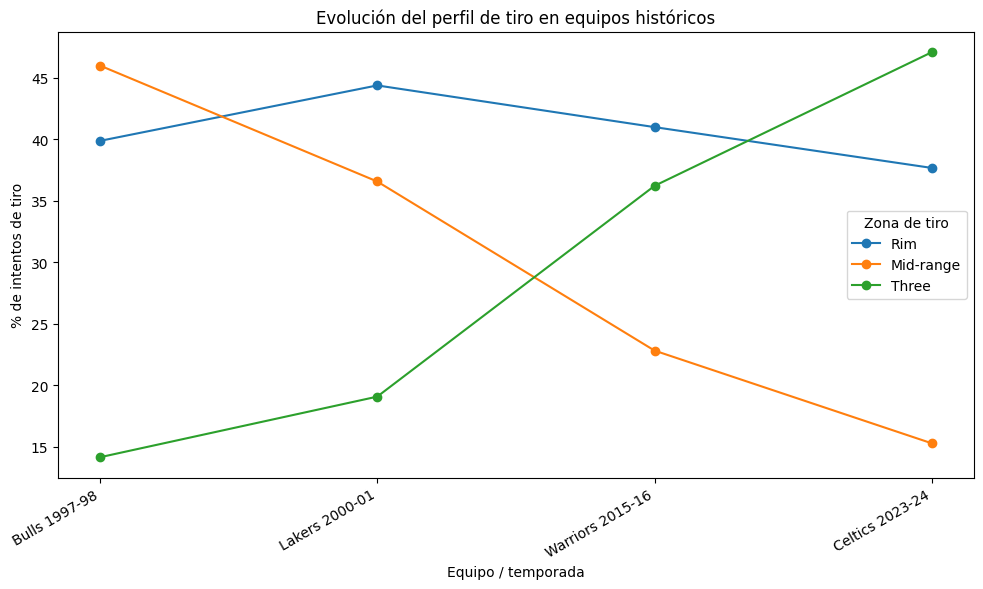

In [139]:
import os
trend_data = historical_profile.copy()

trend_data["TEAM_LABEL"] = pd.Categorical(
    trend_data["TEAM_LABEL"],
    categories=team_order,
    ordered=True
)

trend_data = trend_data.sort_values("TEAM_LABEL")

plt.figure(figsize=(10, 6))

for shot_group in ["Rim", "Mid-range", "Three"]:
    subset = trend_data[trend_data["SHOT_GROUP"] == shot_group]
    plt.plot(
        subset["TEAM_LABEL"],
        subset["FGA_SHARE_PCT"],
        marker="o",
        label=shot_group
    )

plt.title("Evolución del perfil de tiro en equipos históricos")
plt.xlabel("Equipo / temporada")
plt.ylabel("% de intentos de tiro")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Zona de tiro")
plt.tight_layout()

# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/historical_shot_profile_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Métrica Moreyball Rate

In [140]:
moreyball_table = historical_profile.pivot_table(
    index="TEAM_LABEL",
    columns="SHOT_GROUP",
    values="FGA_SHARE_PCT",
    fill_value=0
)

moreyball_table = moreyball_table.reindex(team_order)

moreyball_table["MOREYBALL_RATE"] = (                           # Es la suma de los tiros cerca del aro y de los triples, es decir, la proporción de tiros que se hacen desde las zonas más eficientes según el análisis de Morey.
    moreyball_table["Rim"] + moreyball_table["Three"]
)

moreyball_table["MIDRANGE_RATE"] = moreyball_table["Mid-range"] # Proporción de tiros de media distancia, que es la zona menos eficiente según el análisis de Morey.

moreyball_table

SHOT_GROUP,Mid-range,Rim,Three,MOREYBALL_RATE,MIDRANGE_RATE
TEAM_LABEL,,,,,
Bulls 1997-98,45.99,39.86,14.14,54.00,45.99
Lakers 2000-01,36.56,44.37,19.07,63.44,36.56
Warriors 2015-16,22.81,40.98,36.21,77.19,22.81
Celtics 2023-24,15.27,37.66,47.08,84.74,15.27


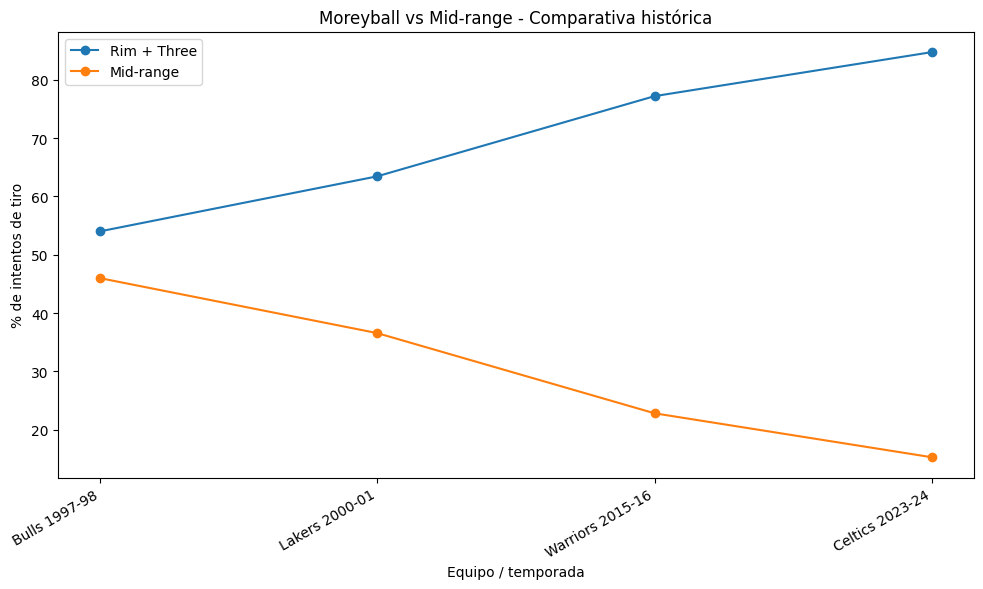

In [141]:
import os
plt.figure(figsize=(10, 6))

plt.plot(
    moreyball_table.index,
    moreyball_table["MOREYBALL_RATE"],
    marker="o",
    label="Rim + Three"
)

plt.plot(
    moreyball_table.index,
    moreyball_table["MIDRANGE_RATE"],
    marker="o",
    label="Mid-range"
)

plt.title("Moreyball vs Mid-range - Comparativa histórica")
plt.xlabel("Equipo / temporada")
plt.ylabel("% de intentos de tiro")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()

# Guardamos la visualización final para reutilizarla en la presentación
os.makedirs("../../reports/img", exist_ok=True)
plt.savefig(
    "../../reports/img/historical_moreyball_vs_midrange.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Conclusiones: tendencias de lanzamiento

El análisis muestra una evolución clara en la selección de tiro entre los equipos históricos estudiados. Los Bulls 1997-98 y los Lakers 2000-01 presentan una mayor presencia relativa de la media distancia, mientras que Warriors 2015-16 y Celtics 2023-24 concentran más volumen en el triple y cerca del aro.

La comparación de puntos por intento ayuda a explicar este cambio. En esta muestra, la media distancia produce menos puntos por intento que el triple o los tiros cerca del aro. Esto no significa que el mid-range sea inútil, sino que ha dejado de ser una zona prioritaria para el ataque promedio.

La tendencia encaja con la lógica del Moreyball: maximizar tiros de mayor valor esperado, especialmente triples y lanzamientos cerca del aro. Esta conclusión conecta con la segunda rama del proyecto, centrada en los jugadores o equipos que funcionan como outliers y siguen explotando la media distancia de forma eficiente.

## Limitaciones del análisis

Este análisis compara equipos históricos concretos, no todas las temporadas completas de la NBA. Por tanto, las conclusiones deben interpretarse como una muestra representativa de distintas etapas del juego, no como una demostración exhaustiva de toda la liga.

Además, la clasificación de tiro en Rim, Mid-range y Three se ha simplificado usando la distancia del lanzamiento y el tipo de tiro. Esta aproximación es útil para el EDA, aunque no captura todos los matices tácticos del juego.

## Exportación de resultados finales

Guardamos los datasets procesados y las visualizaciones principales generadas durante el análisis para poder reutilizarlas en la presentación final del proyecto.

In [142]:
import os

processed_path = "../../data/processed/carlos"
img_path = "../../reports/img"

os.makedirs(processed_path, exist_ok=True)
os.makedirs(img_path, exist_ok=True)

In [143]:
# Dataset individual de Boston con clasificación de tiros
shots_df.to_csv(
    f"{processed_path}/boston_celtics_shots_2023_24_with_groups.csv",
    index=False
)

# Resumen de distribución de tiros de Boston
shot_group_summary.to_csv(
    f"{processed_path}/boston_celtics_shot_group_summary_2023_24.csv",
    index=False
)

# Eficiencia / puntos por intento de Boston
zone_efficiency.to_csv(
    f"{processed_path}/boston_celtics_zone_efficiency_2023_24.csv",
    index=False
)

# Dataset histórico completo
historical_shots.to_csv(
    f"{processed_path}/historical_team_shots.csv",
    index=False
)

# Perfil histórico por equipo y zona
historical_profile.to_csv(
    f"{processed_path}/historical_team_shot_profile.csv",
    index=False
)

# Tabla resumen final
summary_table.to_csv(
    f"{processed_path}/historical_summary_table.csv"
)

# Tabla Moreyball
moreyball_table.to_csv(
    f"{processed_path}/historical_moreyball_table.csv"
)

print("Datasets y tablas guardados correctamente.")

Datasets y tablas guardados correctamente.


### Comprobación de archivos exportados


In [144]:
saved_tables = [
    f"{processed_path}/boston_celtics_shots_2023_24_with_groups.csv",
    f"{processed_path}/boston_celtics_shot_group_summary_2023_24.csv",
    f"{processed_path}/boston_celtics_zone_efficiency_2023_24.csv",
    f"{processed_path}/historical_team_shots.csv",
    f"{processed_path}/historical_team_shot_profile.csv",
    f"{processed_path}/historical_summary_table.csv",
    f"{processed_path}/historical_moreyball_table.csv",
]

saved_images = [
    f"{img_path}/shot_chart_boston_celtics_2023_24.png",
    f"{img_path}/historical_shot_distribution.png",
    f"{img_path}/historical_points_per_attempt.png",
    f"{img_path}/historical_moreyball_vs_midrange.png",
    f"{img_path}/historical_shot_profile_trend.png",
    f"{img_path}/shot_chart_matrix_spatial_distribution.png",
    f"{img_path}/shot_chart_matrix_density_log.png",
    f"{img_path}/shot_chart_matrix_made_vs_missed.png",
]

print("Comprobación de tablas:")
for file in saved_tables:
    print(file, "->", os.path.exists(file))

print()
print("Comprobación de imágenes:")
for file in saved_images:
    print(file, "->", os.path.exists(file))


Comprobación de tablas:
../../data/processed/carlos/boston_celtics_shots_2023_24_with_groups.csv -> True
../../data/processed/carlos/boston_celtics_shot_group_summary_2023_24.csv -> True
../../data/processed/carlos/boston_celtics_zone_efficiency_2023_24.csv -> True
../../data/processed/carlos/historical_team_shots.csv -> True
../../data/processed/carlos/historical_team_shot_profile.csv -> True
../../data/processed/carlos/historical_summary_table.csv -> True
../../data/processed/carlos/historical_moreyball_table.csv -> True

Comprobación de imágenes:
../../reports/img/shot_chart_boston_celtics_2023_24.png -> True
../../reports/img/historical_shot_distribution.png -> True
../../reports/img/historical_points_per_attempt.png -> True
../../reports/img/historical_moreyball_vs_midrange.png -> True
../../reports/img/historical_shot_profile_trend.png -> True
../../reports/img/shot_chart_matrix_spatial_distribution.png -> True
../../reports/img/shot_chart_matrix_density_log.png -> True
../../rep